In [5]:
import pandas as pd

df = pd.read_csv("Forecasting Case- Study Sheet1.csv")

print(df.head())
print(df.columns)
print(df.shape)


        State       Date           Total   Category
0     Alabama  1/12/2019    109,574,036   Beverages
1     Arizona  1/12/2019    109,101,595   Beverages
2    Arkansas  1/12/2019     58,049,432   Beverages
3  California  1/12/2019    444,766,891   Beverages
4    Colorado  1/12/2019     89,816,716   Beverages
Index(['State', 'Date', 'Total', 'Category'], dtype='object')
(8084, 4)


In [9]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [10]:
print(df.isnull().sum())

State          0
Date        4859
Total          0
Category       0
dtype: int64


In [11]:
print(df.info())
print(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8084 entries, 0 to 8083
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   State     8084 non-null   object        
 1   Date      3225 non-null   datetime64[ns]
 2   Total     8084 non-null   object        
 3   Category  8084 non-null   object        
dtypes: datetime64[ns](1), object(3)
memory usage: 252.8+ KB
None
                      Date
count                 3225
mean   2021-07-28 00:00:00
min    2019-01-12 00:00:00
25%    2020-08-11 00:00:00
50%    2021-07-11 00:00:00
75%    2022-06-11 00:00:00
max    2023-12-03 00:00:00


In [13]:
df['Total'] = df['Total'].str.replace(',', '')

df['Total'] = df['Total'].astype(float)

In [14]:
print(df['Total'].head())
print(df['Total'].dtype)

0    109574036.0
1    109101595.0
2     58049432.0
3    444766891.0
4     89816716.0
Name: Total, dtype: float64
float64


In [15]:
df['Date'] = pd.to_datetime(df['Date'])

In [16]:
print(df['Date'].dtype)

datetime64[ns]


In [17]:
df = df.sort_values(['State', 'Date'])

In [18]:
df = df.rename(columns={
    'Total': 'Sales'
})

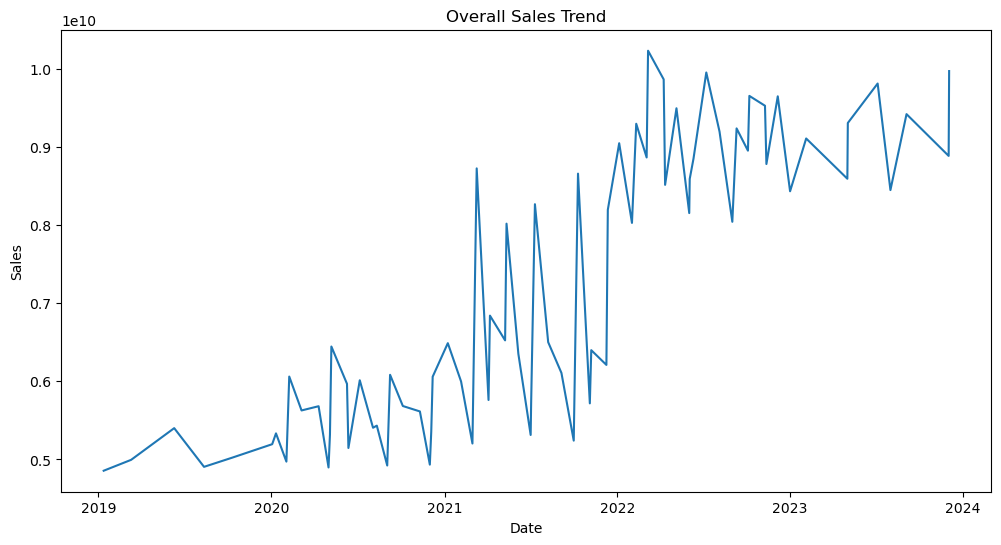

In [19]:
import matplotlib.pyplot as plt

daily_sales = df.groupby('Date')['Sales'].sum()

plt.figure(figsize=(12,6))

plt.plot(daily_sales.index, daily_sales.values)

plt.title("Overall Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

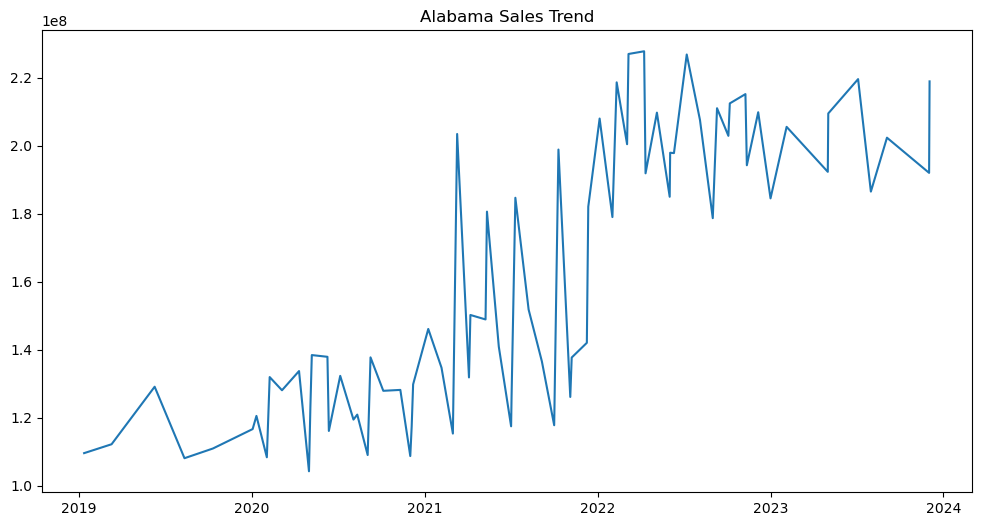

In [20]:
state_df = df[df['State'] == 'Alabama']

plt.figure(figsize=(12,6))

plt.plot(state_df['Date'], state_df['Sales'])

plt.title("Alabama Sales Trend")

plt.show()

In [23]:
state_df = state_df.groupby('Date')['Sales'].sum().reset_index()

In [24]:
state_df = state_df.set_index('Date')

all_dates = pd.date_range(
    start=state_df.index.min(),
    end=state_df.index.max(),
    freq='W'
)

state_df = state_df.reindex(all_dates)

In [25]:
state_df['Sales'] = state_df['Sales'].interpolate()

In [26]:
state_df = state_df.reset_index()

state_df = state_df.rename(columns={
    'index': 'Date'
})

In [27]:
state_df['lag_1'] = state_df['Sales'].shift(1)

state_df['lag_7'] = state_df['Sales'].shift(7)

state_df['lag_30'] = state_df['Sales'].shift(30)

In [28]:
state_df['rolling_mean_7'] = (
    state_df['Sales']
    .rolling(window=7)
    .mean()
)

In [29]:
state_df['month'] = state_df['Date'].dt.month

In [30]:
state_df['week'] = (
    state_df['Date']
    .dt.isocalendar()
    .week
)

In [31]:
pip install holidays

In [32]:
import holidays

india_holidays = holidays.India()

state_df['is_holiday'] = state_df['Date'].apply(
    lambda x: 1 if x in india_holidays else 0
)

In [33]:
state_df = state_df.dropna()

In [35]:
features = [
    'lag_1',
    'lag_7',
    'lag_30',
    'rolling_mean_7',
    'rolling_std_7',
    'month',
    'week',
    'quarter',
    'is_holiday'
]

In [47]:
state_df['rolling_std_7'] = state_df['Sales'].rolling(7).std()
state_df['quarter'] = state_df['Date'].dt.quarter

In [49]:
print(state_df.columns)

Index(['Date', 'Sales', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'month',
       'week', 'is_holiday', 'rolling_std_7', 'quarter'],
      dtype='object')


In [50]:
train = state_df.iloc[:-8]
test = state_df.iloc[-8:]

In [51]:
X_train = train[features]

y_train = train['Sales']

X_test = test[features]

y_test = test['Sales']

In [52]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [53]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [54]:
predictions = model.predict(X_test)

In [55]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, predictions)

print("MAE:", mae)

MAE: 3793998.364583336


In [67]:
from sklearn.metrics import mean_squared_error
import numpy as np

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, predictions)
)

print("RMSE:",xgb_rmse)

RMSE: 4134258.737639249


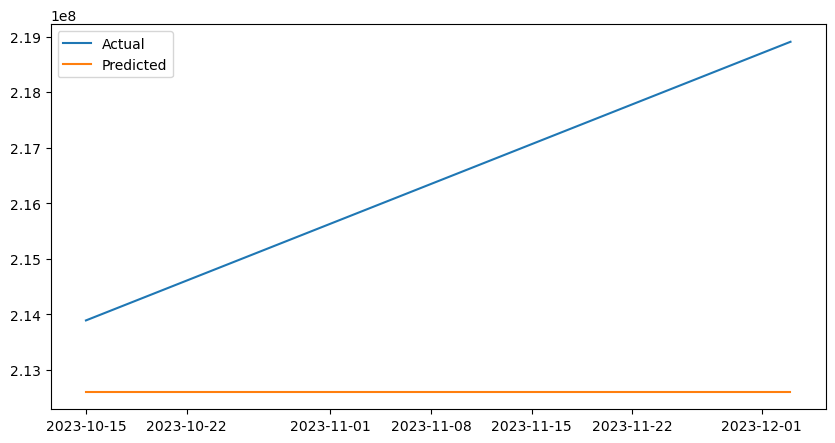

In [68]:
plt.figure(figsize=(10,5))

plt.plot(
    test['Date'],
    y_test,
    label='Actual'
)

plt.plot(
    test['Date'],
    predictions,
    label='Predicted'
)

plt.legend()

plt.show()

In [69]:
import joblib

joblib.dump(model, '../models/xgboost_model.pkl')

['../models/xgboost_model.pkl']

In [76]:
xgb_rmse = 4134258.737639249
sarima_rmse = 5381222.401307351
prophet_rmse = 7758154.107062888
lstm_rmse = 1424079.093277045

In [77]:
results = {
    'XGBoost': xgb_rmse,
    'SARIMA': sarima_rmse,
    'Prophet': prophet_rmse,
    'LSTM': lstm_rmse
}

In [79]:
Best_model = min(results, key=results.get)
print("Best model:", Best_model)
print("Best model RMSE:", results[Best_model])


Best model: LSTM
Best model RMSE: 1424079.093277045
